<a href="https://colab.research.google.com/github/Joydas2003/Electrical-Load-Forcasting-Ml/blob/master/Machine%20Learning%20Based%20short%20term%20Electrical%20Load%20Forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')
pgcb_df=pd.read_csv( "/content/drive/MyDrive/Load Forcasting/PGCB_date_power_demand.csv")
nasa_df=pd.read_csv("/content/drive/MyDrive/Load Forcasting/Hourly_Temp_Humidity (2).csv")
from IPython.display import display

display(pgcb_df)
display(nasa_df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks
0,4/19/2015 22:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,4/19/2015 21:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,4/19/2015 19:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,4/19/2015 18:30,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,4/19/2015 18:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92645,6/17/2025 4:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN
92646,6/17/2025 3:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN
92647,6/17/2025 2:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN
92648,6/17/2025 1:00,14093.0,14115,21,6323,1350,4019,172,0.0,28.0,924,38,1201.0,38.0,NaN


,datetime,Temperature_C,Humidity_%
0,2015-01-19 00:00:00,13.79,66.79
1,2015-01-19 01:00:00,13.25,69.37
2,2015-01-19 02:00:00,12.73,72.19
3,2015-01-19 03:00:00,12.21,75.48
4,2015-01-19 04:00:00,11.78,78.84
...,...,...,...
91267,2025-06-17 19:00:00,26.98,95.39
91268,2025-06-17 20:00:00,26.81,96.40
91269,2025-06-17 21:00:00,26.70,96.67
91270,2025-06-17 22:00:00,26.61,96.64


In [3]:
# Date column গুলো ensure করা datetime format এ আছে
pgcb_df['datetime'] = pd.to_datetime(pgcb_df['datetime'])
nasa_df['datetime'] = pd.to_datetime(nasa_df['datetime'])

# Merge করা, left join করলে সব PGCB date থাকবে
df = pd.merge(pgcb_df, nasa_df, on='datetime', how='left')

# Display
from IPython.display import display
display(df)

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.48,84.04
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.92,80.84
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN,28.49,70.64
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak,NaN,NaN
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN,29.50,65.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92645,2025-06-17 04:00:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN,26.71,95.81
92646,2025-06-17 03:00:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN,26.79,95.97
92647,2025-06-17 02:00:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN,26.83,96.17
92648,2025-06-17 01:00:00,14093.0,14115,21,6323,1350,4019,172,0.0,28.0,924,38,1201.0,38.0,NaN,26.87,96.23


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   datetime                92650 non-null  datetime64[ns]
 1   generation_mw           92650 non-null  float64       
 2   demand_mw               92650 non-null  int64         
 3   load_shedding           92650 non-null  int64         
 4   gas                     92650 non-null  int64         
 5   liquid_fuel             92650 non-null  int64         
 6   coal                    92650 non-null  int64         
 7   hydro                   92650 non-null  int64         
 8   solar                   70517 non-null  float64       
 9   wind                    18676 non-null  float64       
 10  india_bheramara_hvdc    92650 non-null  int64         
 11  india_bheramara_hvdc.1  92650 non-null  int64         
 12  india_bheramara_hvdc.2  7338 non-null   float6

Convert the column datatype to datetime format.

In [5]:
df["datetime"]=pd.to_datetime(df["datetime"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   datetime                92650 non-null  datetime64[ns]
 1   generation_mw           92650 non-null  float64       
 2   demand_mw               92650 non-null  int64         
 3   load_shedding           92650 non-null  int64         
 4   gas                     92650 non-null  int64         
 5   liquid_fuel             92650 non-null  int64         
 6   coal                    92650 non-null  int64         
 7   hydro                   92650 non-null  int64         
 8   solar                   70517 non-null  float64       
 9   wind                    18676 non-null  float64       
 10  india_bheramara_hvdc    92650 non-null  int64         
 11  india_bheramara_hvdc.1  92650 non-null  int64         
 12  india_bheramara_hvdc.2  7338 non-null   float6

In [6]:
df=df.set_index("datetime")
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.48,84.04
2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.92,80.84
2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN,28.49,70.64
2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak,NaN,NaN
2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN,29.50,65.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 04:00:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN,26.71,95.81
2025-06-17 03:00:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN,26.79,95.97
2025-06-17 02:00:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN,26.83,96.17


In [7]:
df.index=pd.to_datetime(df.index)
df=df.sort_index()
df = df.loc['2021-06-17':'2025-06-17']
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2021-06-17 00:00:00,10892.0,10892,0,6883,2416,550,25,0.0,NaN,912,112,NaN,NaN,NaN,26.81,96.14
2021-06-17 01:00:00,10408.0,10408,0,6924,189,550,25,0.0,NaN,912,110,NaN,NaN,NaN,26.52,96.22
2021-06-17 02:00:00,10141.0,10141,0,6901,1651,550,25,0.0,NaN,912,108,NaN,NaN,NaN,26.29,96.42
2021-06-17 03:00:00,9880.0,9880,0,6949,1394,500,25,0.0,NaN,912,106,NaN,NaN,NaN,26.14,96.33
2021-06-17 04:00:00,9596.0,9596,0,6808,1255,500,25,0.0,NaN,902,102,NaN,NaN,NaN,26.01,96.31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,12443.0,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


In [8]:
df.describe()

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,Temperature_C,Humidity_%
count,3.654300e+04,36543.000000,36543.000000,36543.000000,3.654300e+04,36543.000000,36543.000000,36543.000000,18676.000000,36543.000000,36543.000000,7338.000000,5351.000000,35084.000000,35084.000000
mean,1.236216e+04,10811.518020,200.590482,5316.886982,2.763507e+03,2071.389213,89.443368,82.208056,9.233133,819.695208,99.266207,881.196375,0.546814,25.586779,78.295690
std,3.374998e+05,2696.043399,445.171888,1098.918501,1.528661e+05,1321.035193,73.376800,136.344875,16.272517,149.629051,40.090569,369.905673,4.525897,5.446869,18.111371
min,1.026000e+03,143.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.310000,17.900000
25%,9.009000e+03,9050.000000,0.000000,4639.000000,8.350000e+02,837.000000,40.000000,0.000000,0.000000,732.000000,72.000000,702.000000,0.000000,22.410000,67.730000
50%,1.068200e+04,10812.000000,0.000000,5298.000000,1.746000e+03,1935.000000,70.000000,0.000000,4.000000,900.000000,100.000000,822.000000,0.000000,26.730000,82.590000
75%,1.222450e+04,12581.000000,169.000000,5962.500000,2.893000e+03,3162.000000,144.000000,117.000000,13.000000,921.000000,126.000000,1050.750000,0.000000,29.130000,93.990000
max,6.452650e+07,156050.000000,13800.000000,66662.000000,2.922290e+07,31687.000000,4860.000000,2998.000000,922.000000,9300.000000,1234.000000,12665.000000,38.000000,42.700000,100.000000


Check the missing values

In [9]:
df.isnull().sum()

,0
generation_mw,0
demand_mw,0
load_shedding,0
gas,0
liquid_fuel,0
coal,0
hydro,0
solar,0
wind,17867
india_bheramara_hvdc,0


To show the records that contain any null values

In [10]:
df[df.isna().any(axis=1)]

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2021-06-17 00:00:00,10892.0,10892,0,6883,2416,550,25,0.0,NaN,912,112,NaN,NaN,NaN,26.81,96.14
2021-06-17 01:00:00,10408.0,10408,0,6924,189,550,25,0.0,NaN,912,110,NaN,NaN,NaN,26.52,96.22
2021-06-17 02:00:00,10141.0,10141,0,6901,1651,550,25,0.0,NaN,912,108,NaN,NaN,NaN,26.29,96.42
2021-06-17 03:00:00,9880.0,9880,0,6949,1394,500,25,0.0,NaN,912,106,NaN,NaN,NaN,26.14,96.33
2021-06-17 04:00:00,9596.0,9596,0,6808,1255,500,25,0.0,NaN,902,102,NaN,NaN,NaN,26.01,96.31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 07:00:00,11745.0,11745,0,5614,494,3487,132,128.0,28.0,924,26,874.0,38.0,NaN,28.00,91.76
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07


To show the records that contain all null values

In [11]:
df[df.isna().all(axis=1)]

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,


Drop those rows that contain all missing values

In [12]:
df=df.dropna(how="all")
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2021-06-17 00:00:00,10892.0,10892,0,6883,2416,550,25,0.0,NaN,912,112,NaN,NaN,NaN,26.81,96.14
2021-06-17 01:00:00,10408.0,10408,0,6924,189,550,25,0.0,NaN,912,110,NaN,NaN,NaN,26.52,96.22
2021-06-17 02:00:00,10141.0,10141,0,6901,1651,550,25,0.0,NaN,912,108,NaN,NaN,NaN,26.29,96.42
2021-06-17 03:00:00,9880.0,9880,0,6949,1394,500,25,0.0,NaN,912,106,NaN,NaN,NaN,26.14,96.33
2021-06-17 04:00:00,9596.0,9596,0,6808,1255,500,25,0.0,NaN,902,102,NaN,NaN,NaN,26.01,96.31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,12443.0,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


Backwaer Fill -bfill

Forward Fill -ffill

In [13]:
df.index = pd.to_datetime(df.index)
df = df.sort_index()
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2021-06-17 00:00:00,10892.0,10892,0,6883,2416,550,25,0.0,NaN,912,112,NaN,NaN,NaN,26.81,96.14
2021-06-17 01:00:00,10408.0,10408,0,6924,189,550,25,0.0,NaN,912,110,NaN,NaN,NaN,26.52,96.22
2021-06-17 02:00:00,10141.0,10141,0,6901,1651,550,25,0.0,NaN,912,108,NaN,NaN,NaN,26.29,96.42
2021-06-17 03:00:00,9880.0,9880,0,6949,1394,500,25,0.0,NaN,912,106,NaN,NaN,NaN,26.14,96.33
2021-06-17 04:00:00,9596.0,9596,0,6808,1255,500,25,0.0,NaN,902,102,NaN,NaN,NaN,26.01,96.31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,12443.0,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


In [14]:
type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [15]:
df.columns

Index(['generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel',
       'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_bheramara_hvdc.1', 'india_bheramara_hvdc.2',
       'india_bheramara_hvdc.3', 'remarks', 'Temperature_C', 'Humidity_%'],
      dtype='object')

In [16]:
cols = [
 'demand_mw', 'generation_mw',
 'gas', 'coal', 'hydro',
 'solar', 'wind', 'liquid_fuel',
 'india_bheramara_hvdc','Temperature_C','Humidity_%'
]
df[cols] = df[cols].interpolate(method='time')
df[cols] = df[cols].ffill().bfill()
df


,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2021-06-17 00:00:00,10892.0,10892,0,6883,2416,550,25,0.0,3.0,912,112,NaN,NaN,NaN,26.81,96.14
2021-06-17 01:00:00,10408.0,10408,0,6924,189,550,25,0.0,3.0,912,110,NaN,NaN,NaN,26.52,96.22
2021-06-17 02:00:00,10141.0,10141,0,6901,1651,550,25,0.0,3.0,912,108,NaN,NaN,NaN,26.29,96.42
2021-06-17 03:00:00,9880.0,9880,0,6949,1394,500,25,0.0,3.0,912,106,NaN,NaN,NaN,26.14,96.33
2021-06-17 04:00:00,9596.0,9596,0,6808,1255,500,25,0.0,3.0,902,102,NaN,NaN,NaN,26.01,96.31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,12443.0,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


In [17]:
df.columns

Index(['generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel',
       'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_bheramara_hvdc.1', 'india_bheramara_hvdc.2',
       'india_bheramara_hvdc.3', 'remarks', 'Temperature_C', 'Humidity_%'],
      dtype='object')

In [18]:
df.isna().sum()

,0
generation_mw,0
demand_mw,0
load_shedding,0
gas,0
liquid_fuel,0
coal,0
hydro,0
solar,0
wind,0
india_bheramara_hvdc,0


create the quarter column in the dataset

Feature Engineering

In [19]:
df.insert(0,"hour",df.index.hour)
df.insert(2,'month',df.index.month)
df.insert(3,'year',df.index.year)
df['day_of_week'] = df.index.dayofweek

# Month (yearly cycle)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Weekend flag
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df

,hour,generation_mw,month,year,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,...,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%,day_of_week,month_sin,month_cos,is_weekend
datetime,,,,,,,,,,,,,,,,,,,,,
2021-06-17 00:00:00,0,10892.0,6,2021,10892,0,6883,2416,550,25,...,112,NaN,NaN,NaN,26.81,96.14,3,1.224647e-16,-1.0,0
2021-06-17 01:00:00,1,10408.0,6,2021,10408,0,6924,189,550,25,...,110,NaN,NaN,NaN,26.52,96.22,3,1.224647e-16,-1.0,0
2021-06-17 02:00:00,2,10141.0,6,2021,10141,0,6901,1651,550,25,...,108,NaN,NaN,NaN,26.29,96.42,3,1.224647e-16,-1.0,0
2021-06-17 03:00:00,3,9880.0,6,2021,9880,0,6949,1394,500,25,...,106,NaN,NaN,NaN,26.14,96.33,3,1.224647e-16,-1.0,0
2021-06-17 04:00:00,4,9596.0,6,2021,9596,0,6808,1255,500,25,...,102,NaN,NaN,NaN,26.01,96.31,3,1.224647e-16,-1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,11896,0,5678,490,3470,132,...,24,864.0,38.0,NaN,28.74,87.73,1,1.224647e-16,-1.0,0
2025-06-17 09:00:00,9,12290.0,6,2025,12290,0,6065,531,3491,132,...,24,866.0,38.0,NaN,29.37,84.07,1,1.224647e-16,-1.0,0
2025-06-17 10:00:00,10,12443.0,6,2025,12443,0,5900,552,3601,172,...,26,985.0,38.0,NaN,29.77,81.71,1,1.224647e-16,-1.0,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 36543 entries, 2021-06-17 00:00:00 to 2025-06-17 12:00:00
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   hour                    36543 non-null  int32  
 1   generation_mw           36543 non-null  float64
 2   month                   36543 non-null  int32  
 3   year                    36543 non-null  int32  
 4   demand_mw               36543 non-null  int64  
 5   load_shedding           36543 non-null  int64  
 6   gas                     36543 non-null  int64  
 7   liquid_fuel             36543 non-null  int64  
 8   coal                    36543 non-null  int64  
 9   hydro                   36543 non-null  int64  
 10  solar                   36543 non-null  float64
 11  wind                    36543 non-null  float64
 12  india_bheramara_hvdc    36543 non-null  int64  
 13  india_bheramara_hvdc.1  36543 non-null  int64  
 14  ind

Laged Features : These are the past values of a time series data.

Use- past demand values are strong predictors.They can be used as input to predict future values.

In [21]:
#Demand from the same hour yesterday, same hour last week.
df['Demand_lag_24hr']=df["demand_mw"].shift(24)
df['Demand_lag_168hr']=df["demand_mw"].shift(168) #24*7=168 hour for week shift
df

,hour,generation_mw,month,year,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,...,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%,day_of_week,month_sin,month_cos,is_weekend,Demand_lag_24hr,Demand_lag_168hr
datetime,,,,,,,,,,,,,,,,,,,,,
2021-06-17 00:00:00,0,10892.0,6,2021,10892,0,6883,2416,550,25,...,NaN,NaN,26.81,96.14,3,1.224647e-16,-1.0,0,NaN,NaN
2021-06-17 01:00:00,1,10408.0,6,2021,10408,0,6924,189,550,25,...,NaN,NaN,26.52,96.22,3,1.224647e-16,-1.0,0,NaN,NaN
2021-06-17 02:00:00,2,10141.0,6,2021,10141,0,6901,1651,550,25,...,NaN,NaN,26.29,96.42,3,1.224647e-16,-1.0,0,NaN,NaN
2021-06-17 03:00:00,3,9880.0,6,2021,9880,0,6949,1394,500,25,...,NaN,NaN,26.14,96.33,3,1.224647e-16,-1.0,0,NaN,NaN
2021-06-17 04:00:00,4,9596.0,6,2021,9596,0,6808,1255,500,25,...,NaN,NaN,26.01,96.31,3,1.224647e-16,-1.0,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,11896,0,5678,490,3470,132,...,38.0,NaN,28.74,87.73,1,1.224647e-16,-1.0,0,13155.0,12403.0
2025-06-17 09:00:00,9,12290.0,6,2025,12290,0,6065,531,3491,132,...,38.0,NaN,29.37,84.07,1,1.224647e-16,-1.0,0,13569.0,12072.0
2025-06-17 10:00:00,10,12443.0,6,2025,12443,0,5900,552,3601,172,...,38.0,NaN,29.77,81.71,1,1.224647e-16,-1.0,0,13816.0,11377.0


In [22]:
#Rolling Mean and rolling standard deviation
df["demand_rolling_mean_24hr"]=df["demand_mw"].rolling(window=24).mean()

In [23]:
df["demand_rolling_mean_48hr"] = df["demand_mw"].rolling(window=48).mean()

In [24]:
df["demand_ema_24hr"] = df["demand_mw"].ewm(span=24, adjust=False).mean()

In [25]:
df["temp_rolling_mean_24hr"] = df["Temperature_C"].rolling(24).mean()
df['coal_share'] = df['coal'] / df['generation_mw']

In [26]:
# Non-renewable sources
gas = df['gas'].sum()
liquid_fuel = df['liquid_fuel'].sum()
coal = df['coal'].sum()

# Renewable sources (combine)
renewable = df[['hydro','solar','wind']].sum().sum()

# India import combine
india_import = df[['india_bheramara_hvdc',
                   'india_bheramara_hvdc.1',
                   'india_bheramara_hvdc.2',
                   'india_bheramara_hvdc.3']].sum().sum()

# Create dictionary
energy_sources = {
    'Gas': gas,
    'Liquid Fuel': liquid_fuel,
    'Coal': coal,
    'Renewable (Hydro+Solar+Wind)': renewable,
    'India Import': india_import
}

# Convert to pandas series
source_generation = pd.Series(energy_sources)

# Total generation
total_generation = source_generation.sum()

# Percentage
source_percent = (source_generation / total_generation) * 100

print(source_percent)

Gas                             46.534896
Liquid Fuel                     24.186997
Coal                            18.129383
Renewable (Hydro+Solar+Wind)     1.556311
India Import                     9.592411
dtype: float64


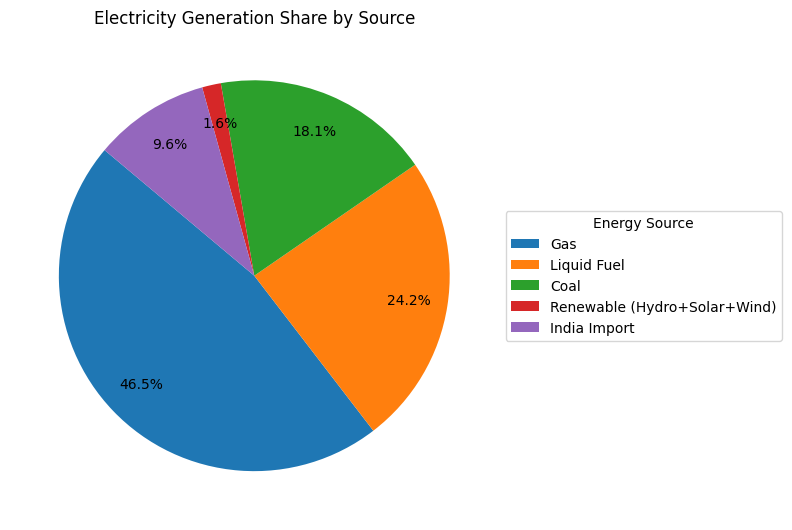

In [27]:

plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    source_percent.values,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8
)

# legend use instead of labels on pie
plt.legend(
    wedges,
    source_percent.index,
    title="Energy Source",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Electricity Generation Share by Source")

plt.tight_layout()
plt.show()

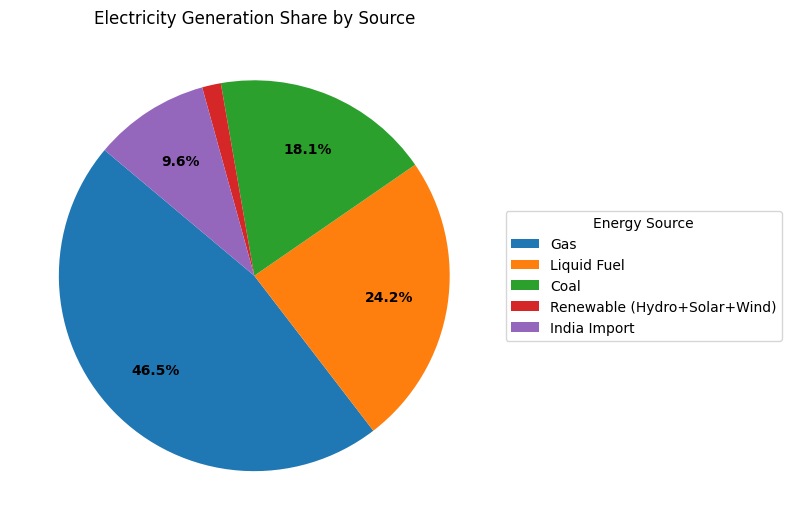

In [28]:

plt.figure(figsize=(8, 8))

wedges, texts, autotexts = plt.pie(
    source_percent.values,
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',  # ছোট % hide
    startangle=140,
    pctdistance=0.7,  # percentage ভিতরে রাখা
    textprops={'fontsize': 10}
)

# Percentage text style
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_weight('bold')

# Legend (clean look)
plt.legend(
    wedges,
    source_percent.index,
    title="Energy Source",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Electricity Generation Share by Source")

plt.tight_layout()
plt.show()

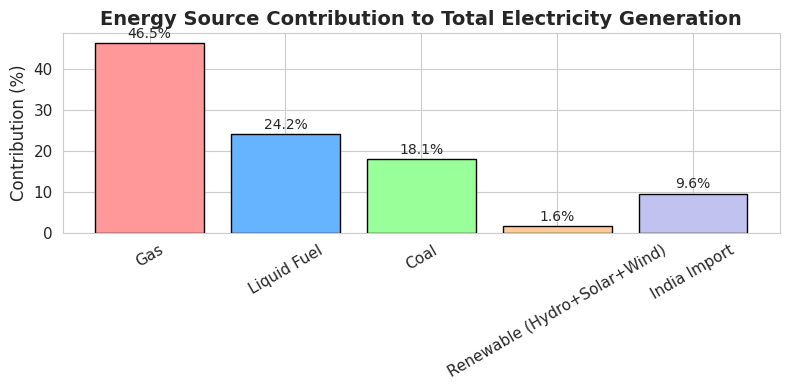

In [29]:

# Set style
sns.set_style("whitegrid")

plt.figure(figsize=(8,4))

# Custom colors (renewable highlighted)
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0']  # Gas, Liquid, Coal, Renewable, India Import

bars = plt.bar(
    source_percent.index,
    source_percent.values,
    color=colors,
    edgecolor='black'
)

# Annotate values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,  # small gap
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Labels and title
plt.ylabel('Contribution (%)', fontsize=12)
plt.title('Energy Source Contribution to Total Electricity Generation', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

In [30]:
df.columns

Index(['hour', 'generation_mw', 'month', 'year', 'demand_mw', 'load_shedding',
       'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind',
       'india_bheramara_hvdc', 'india_bheramara_hvdc.1',
       'india_bheramara_hvdc.2', 'india_bheramara_hvdc.3', 'remarks',
       'Temperature_C', 'Humidity_%', 'day_of_week', 'month_sin', 'month_cos',
       'is_weekend', 'Demand_lag_24hr', 'Demand_lag_168hr',
       'demand_rolling_mean_24hr', 'demand_rolling_mean_48hr',
       'demand_ema_24hr', 'temp_rolling_mean_24hr', 'coal_share'],
      dtype='object')

In [31]:
cols_to_drop = [
     'load_shedding','liquid_fuel',
    'hydro', 'solar', 'wind',
    'india_bheramara_hvdc', 'india_bheramara_hvdc.1',
    'india_bheramara_hvdc.2', 'india_bheramara_hvdc.3',
    'remarks','liquid_fuel','hydro','solar','wind'
]

df.drop(columns=cols_to_drop, inplace=True)
df


,hour,generation_mw,month,year,demand_mw,gas,coal,Temperature_C,Humidity_%,day_of_week,month_sin,month_cos,is_weekend,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share
datetime,,,,,,,,,,,,,,,,,,,,
2021-06-17 00:00:00,0,10892.0,6,2021,10892,6883,550,26.81,96.14,3,1.224647e-16,-1.0,0,NaN,NaN,NaN,NaN,10892.000000,NaN,0.050496
2021-06-17 01:00:00,1,10408.0,6,2021,10408,6924,550,26.52,96.22,3,1.224647e-16,-1.0,0,NaN,NaN,NaN,NaN,10853.280000,NaN,0.052844
2021-06-17 02:00:00,2,10141.0,6,2021,10141,6901,550,26.29,96.42,3,1.224647e-16,-1.0,0,NaN,NaN,NaN,NaN,10796.297600,NaN,0.054235
2021-06-17 03:00:00,3,9880.0,6,2021,9880,6949,500,26.14,96.33,3,1.224647e-16,-1.0,0,NaN,NaN,NaN,NaN,10722.993792,NaN,0.050607
2021-06-17 04:00:00,4,9596.0,6,2021,9596,6808,500,26.01,96.31,3,1.224647e-16,-1.0,0,NaN,NaN,NaN,NaN,10632.834289,NaN,0.052105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,11896,5678,3470,28.74,87.73,1,1.224647e-16,-1.0,0,13155.0,12403.0,13804.000000,14023.041667,13479.928197,28.260000,0.291695
2025-06-17 09:00:00,9,12290.0,6,2025,12290,6065,3491,29.37,84.07,1,1.224647e-16,-1.0,0,13569.0,12072.0,13750.708333,13984.437500,13384.733941,28.239583,0.284052
2025-06-17 10:00:00,10,12443.0,6,2025,12443,5900,3601,29.77,81.71,1,1.224647e-16,-1.0,0,13816.0,11377.0,13693.500000,13950.562500,13309.395226,28.220417,0.289400


In [32]:
df=df.dropna()
df

,hour,generation_mw,month,year,demand_mw,gas,coal,Temperature_C,Humidity_%,day_of_week,month_sin,month_cos,is_weekend,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share
datetime,,,,,,,,,,,,,,,,,,,,
2021-06-23 18:00:00,18,10715.0,6,2021,10715,6454,490,28.35,91.300,2,1.224647e-16,-1.0,0,11923.0,10892.0,10650.041667,10436.958333,10449.199418,27.830000,0.045730
2021-06-23 18:30:00,18,12222.0,6,2021,12222,7055,570,27.98,92.375,2,1.224647e-16,-1.0,0,11970.0,10408.0,10660.541667,10434.166667,10591.023465,27.897500,0.046637
2021-06-23 19:00:00,19,12275.0,6,2021,12275,7073,600,27.61,93.450,2,1.224647e-16,-1.0,0,12106.0,10141.0,10667.583333,10439.500000,10725.741587,27.967083,0.048880
2021-06-23 20:00:00,20,12611.0,6,2021,12611,7173,700,27.17,94.440,2,1.224647e-16,-1.0,0,12145.0,9880.0,10687.000000,10453.750000,10876.562260,28.032083,0.055507
2021-06-23 21:00:00,21,12272.0,6,2021,12272,7204,710,26.84,95.440,2,1.224647e-16,-1.0,0,11810.0,9596.0,10706.250000,10467.395833,10988.197280,28.093750,0.057855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,11896,5678,3470,28.74,87.730,1,1.224647e-16,-1.0,0,13155.0,12403.0,13804.000000,14023.041667,13479.928197,28.260000,0.291695
2025-06-17 09:00:00,9,12290.0,6,2025,12290,6065,3491,29.37,84.070,1,1.224647e-16,-1.0,0,13569.0,12072.0,13750.708333,13984.437500,13384.733941,28.239583,0.284052
2025-06-17 10:00:00,10,12443.0,6,2025,12443,5900,3601,29.77,81.710,1,1.224647e-16,-1.0,0,13816.0,11377.0,13693.500000,13950.562500,13309.395226,28.220417,0.289400


In [33]:
df['demand_mw'].describe()


,demand_mw
count,36375.000000
mean,10816.636619
std,2700.018315
min,143.000000
25%,9050.000000
50%,10821.000000
75%,12597.500000
max,156050.000000


In [34]:
df[df['demand_mw'] > 18000]


,hour,generation_mw,month,year,demand_mw,gas,coal,Temperature_C,Humidity_%,day_of_week,month_sin,month_cos,is_weekend,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share
datetime,,,,,,,,,,,,,,,,,,,,
2023-02-11 18:30:00,18,10052.0,2,2023,104860,4369,1594,22.145,57.490,5,0.866025,0.500000,1,9531.0,6980.0,12544.166667,10457.250000,16541.156105,21.995625,0.158575
2023-04-18 18:30:00,18,15172.0,4,2023,156050,6423,2197,30.810,63.655,1,0.866025,-0.500000,0,15900.0,12911.0,20525.875000,17583.770833,25849.727575,30.694167,0.144806
2023-10-04 09:00:00,9,10587.0,10,2023,20587,5234,3221,27.290,91.420,2,-0.866025,0.500000,0,11779.0,12650.0,12126.625000,12337.250000,12227.818002,27.321250,0.304241
2023-10-11 03:00:00,3,11468.0,10,2023,117000,6021,2965,26.300,84.700,2,-0.866025,0.500000,0,11420.0,10439.0,16801.833333,14554.479167,21049.706911,29.248125,0.258546
2024-04-16 07:00:00,7,11701.0,4,2024,121000,6742,2979,28.270,70.840,1,0.866025,-0.500000,0,11250.0,11416.0,17028.958333,14411.145833,20901.542475,31.497292,0.254594
2024-07-03 05:00:00,5,11080.0,7,2024,111140,5265,3774,26.700,96.650,2,-0.500000,-0.866025,0,11180.0,14200.0,16618.125000,14682.187500,20447.693050,28.504583,0.340614


In [35]:

# Single-cell: Replace outliers

# Calculate IQR (optional for analysis)
Q1 = df['demand_mw'].quantile(0.25)
Q3 = df['demand_mw'].quantile(0.75)
IQR = Q3 - Q1

# Replace extreme values without deleting rows
df['demand_mw'] = df['demand_mw'].clip(lower=5000, upper=18000)

/tmp/ipykernel_8568/1220595872.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['demand_mw'] = df['demand_mw'].clip(lower=5000, upper=18000)


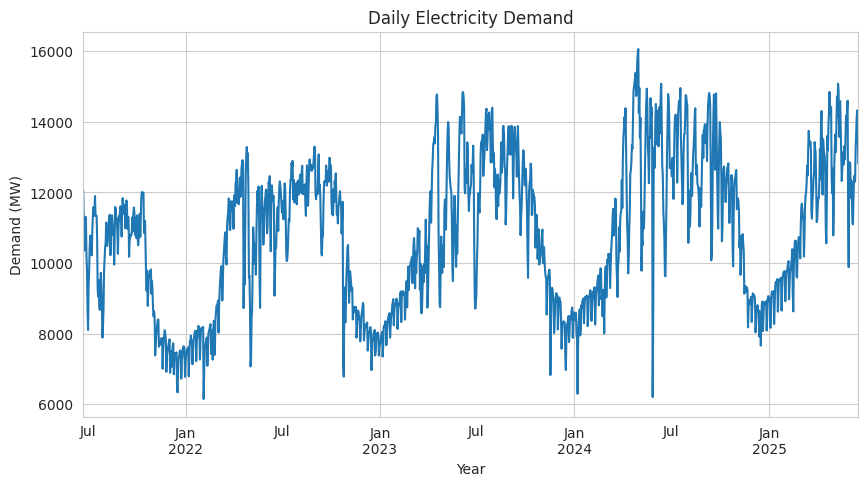

In [36]:
# Daily average demand
df_daily = df['demand_mw'].resample('D').mean().interpolate()

df_daily.plot(figsize=(10,5), title="Daily Electricity Demand")
plt.xlabel("Year")
plt.ylabel("Demand (MW)")
plt.show()


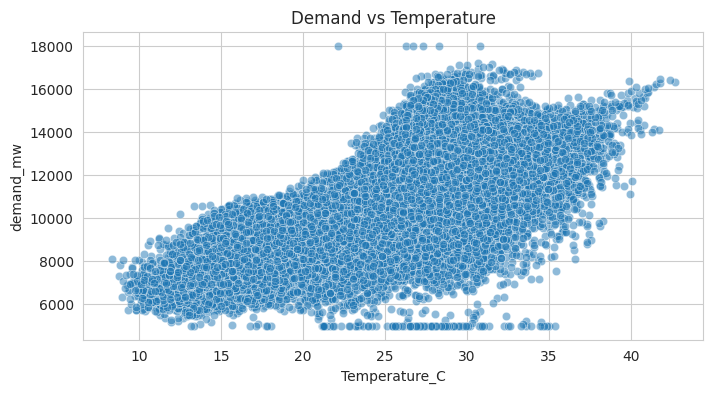

In [37]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=df,x="Temperature_C",y="demand_mw",alpha=0.5)
plt.title("Demand vs Temperature")
plt.show()

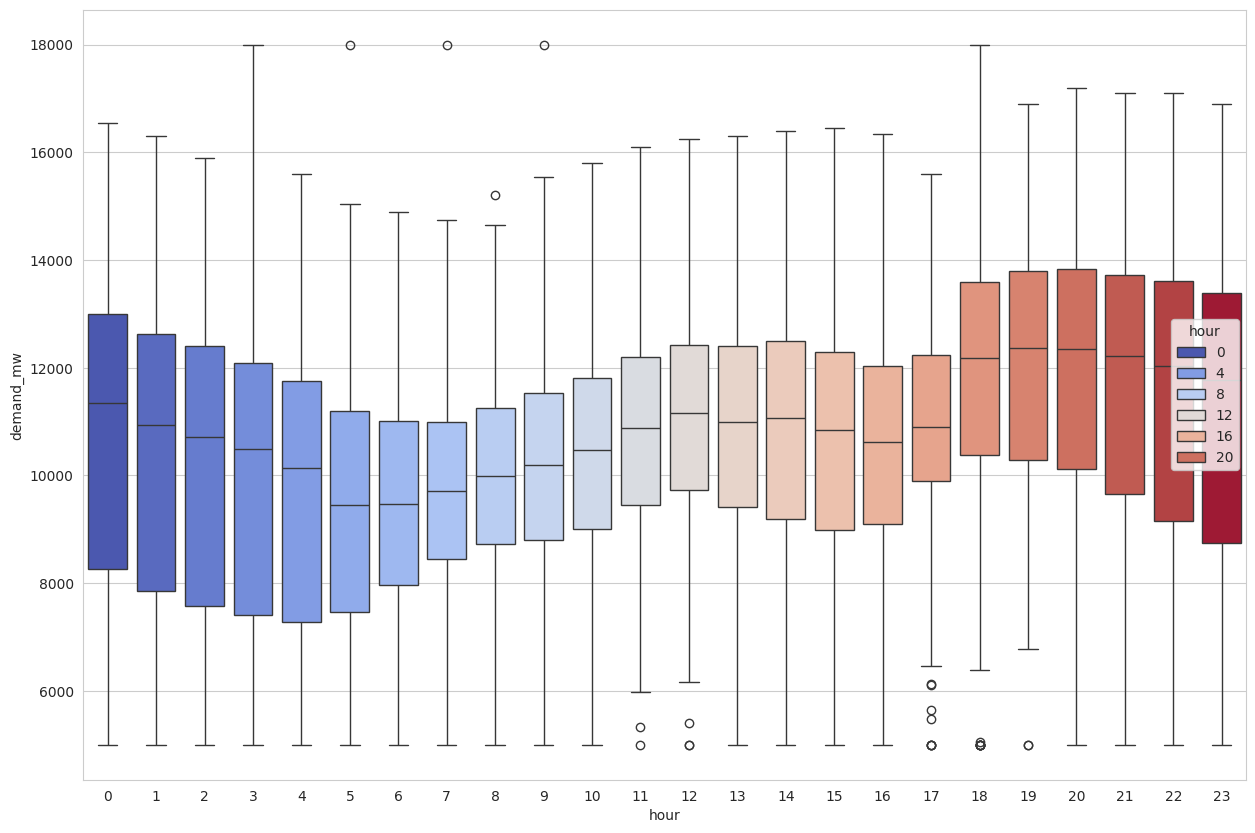

In [38]:
plt.figure(figsize=(15,10))
sns.boxplot(
    x="hour",
    y="demand_mw",
    data=df,
    palette="coolwarm",
    hue="hour",
    #showfliers=False
);


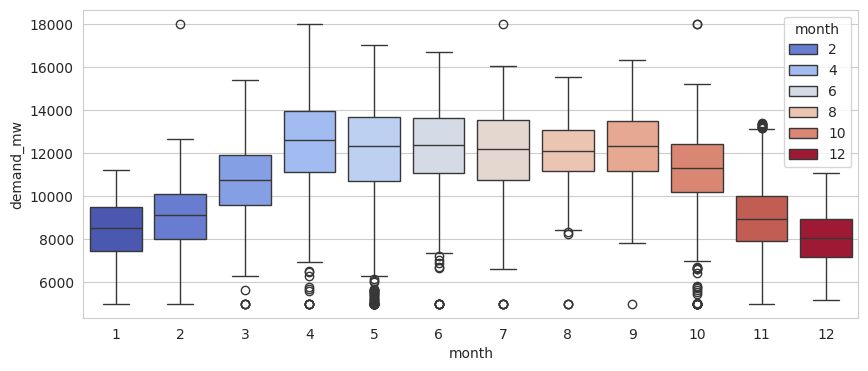

In [39]:
plt.figure(figsize=(10,4))
sns.boxplot(
    x="month",
    y="demand_mw",
    data=df,
    palette="coolwarm",
    hue="month",
    #showfliers=False
);


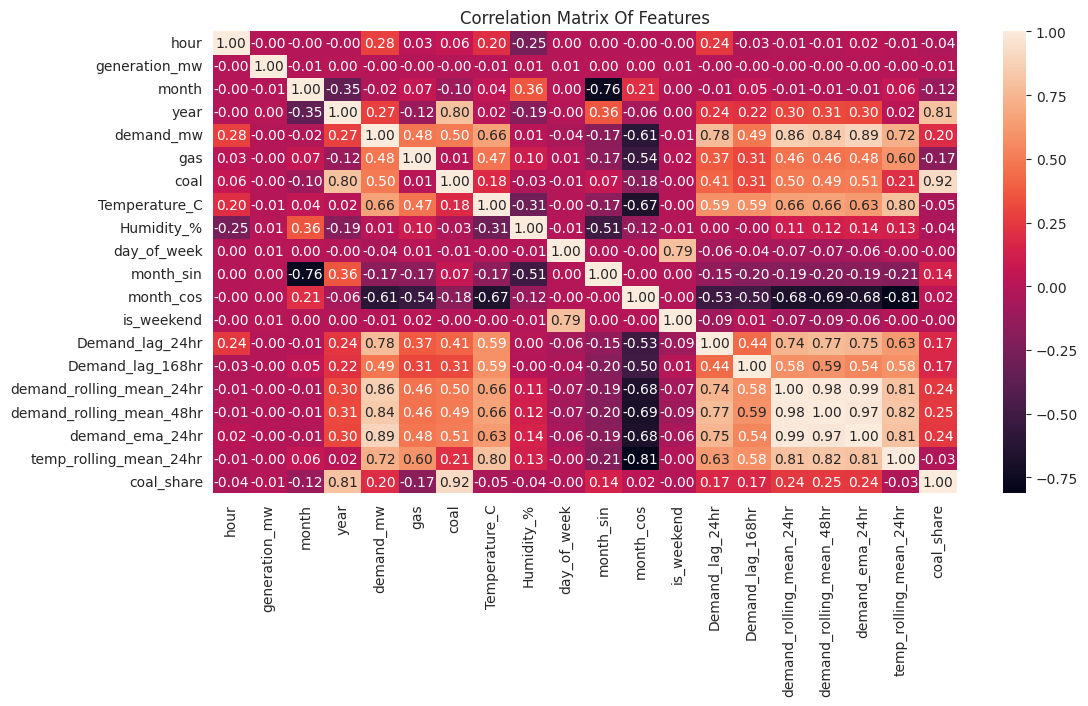

In [40]:
# correlation matrix
plt.figure(figsize=(12,6))
plt.title("Correlation Matrix Of Features")
sns.heatmap(df.corr(),annot=True,fmt=".2f");

In [41]:
#define target variable y
y=df.demand_mw # target variable/ dependent variable
print(y)

datetime
2021-06-23 18:00:00    10715
2021-06-23 18:30:00    12222
2021-06-23 19:00:00    12275
2021-06-23 20:00:00    12611
2021-06-23 21:00:00    12272
                       ...  
2025-06-17 08:00:00    11896
2025-06-17 09:00:00    12290
2025-06-17 10:00:00    12443
2025-06-17 11:00:00    12826
2025-06-17 12:00:00    13139
Name: demand_mw, Length: 36375, dtype: int64


In [42]:
#define Features(x)
x=df.drop("demand_mw",axis=1)  #indipendent variables/ features/predictors
x

,hour,generation_mw,month,year,gas,coal,Temperature_C,Humidity_%,day_of_week,month_sin,month_cos,is_weekend,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share
datetime,,,,,,,,,,,,,,,,,,,
2021-06-23 18:00:00,18,10715.0,6,2021,6454,490,28.35,91.300,2,1.224647e-16,-1.0,0,11923.0,10892.0,10650.041667,10436.958333,10449.199418,27.830000,0.045730
2021-06-23 18:30:00,18,12222.0,6,2021,7055,570,27.98,92.375,2,1.224647e-16,-1.0,0,11970.0,10408.0,10660.541667,10434.166667,10591.023465,27.897500,0.046637
2021-06-23 19:00:00,19,12275.0,6,2021,7073,600,27.61,93.450,2,1.224647e-16,-1.0,0,12106.0,10141.0,10667.583333,10439.500000,10725.741587,27.967083,0.048880
2021-06-23 20:00:00,20,12611.0,6,2021,7173,700,27.17,94.440,2,1.224647e-16,-1.0,0,12145.0,9880.0,10687.000000,10453.750000,10876.562260,28.032083,0.055507
2021-06-23 21:00:00,21,12272.0,6,2021,7204,710,26.84,95.440,2,1.224647e-16,-1.0,0,11810.0,9596.0,10706.250000,10467.395833,10988.197280,28.093750,0.057855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,5678,3470,28.74,87.730,1,1.224647e-16,-1.0,0,13155.0,12403.0,13804.000000,14023.041667,13479.928197,28.260000,0.291695
2025-06-17 09:00:00,9,12290.0,6,2025,6065,3491,29.37,84.070,1,1.224647e-16,-1.0,0,13569.0,12072.0,13750.708333,13984.437500,13384.733941,28.239583,0.284052
2025-06-17 10:00:00,10,12443.0,6,2025,5900,3601,29.77,81.710,1,1.224647e-16,-1.0,0,13816.0,11377.0,13693.500000,13950.562500,13309.395226,28.220417,0.289400


In [43]:
# Splitting the data into training and teating data
x_train=x.loc[ : "2024-06-29"]   #taking 80% 0f data as training data
x_train

,hour,generation_mw,month,year,gas,coal,Temperature_C,Humidity_%,day_of_week,month_sin,month_cos,is_weekend,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share
datetime,,,,,,,,,,,,,,,,,,,
2021-06-23 18:00:00,18,10715.0,6,2021,6454,490,28.35,91.300,2,1.224647e-16,-1.0,0,11923.0,10892.0,10650.041667,10436.958333,10449.199418,27.830000,0.045730
2021-06-23 18:30:00,18,12222.0,6,2021,7055,570,27.98,92.375,2,1.224647e-16,-1.0,0,11970.0,10408.0,10660.541667,10434.166667,10591.023465,27.897500,0.046637
2021-06-23 19:00:00,19,12275.0,6,2021,7073,600,27.61,93.450,2,1.224647e-16,-1.0,0,12106.0,10141.0,10667.583333,10439.500000,10725.741587,27.967083,0.048880
2021-06-23 20:00:00,20,12611.0,6,2021,7173,700,27.17,94.440,2,1.224647e-16,-1.0,0,12145.0,9880.0,10687.000000,10453.750000,10876.562260,28.032083,0.055507
2021-06-23 21:00:00,21,12272.0,6,2021,7204,710,26.84,95.440,2,1.224647e-16,-1.0,0,11810.0,9596.0,10706.250000,10467.395833,10988.197280,28.093750,0.057855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-29 19:00:00,19,13796.0,6,2024,5658,3119,28.25,95.390,5,1.224647e-16,-1.0,1,13720.0,13200.0,12585.708333,12638.375000,12528.059371,28.941458,0.226080
2024-06-29 20:00:00,20,13783.0,6,2024,5607,3122,28.10,95.780,5,1.224647e-16,-1.0,1,13725.0,12753.0,12611.750000,12630.041667,12673.814621,28.962708,0.226511
2024-06-29 21:00:00,21,13740.0,6,2024,5611,3156,28.03,95.710,5,1.224647e-16,-1.0,1,14100.0,12581.0,12626.333333,12624.833333,12815.909452,28.986458,0.229694


In [44]:
y_train=y.loc[ : "2024-06-29"]   #taking 80% 0f data as training data
y_train

,demand_mw
datetime,
2021-06-23 18:00:00,10715
2021-06-23 18:30:00,12222
2021-06-23 19:00:00,12275
2021-06-23 20:00:00,12611
2021-06-23 21:00:00,12272
...,...
2024-06-29 19:00:00,14000
2024-06-29 20:00:00,14350
2024-06-29 21:00:00,14450


In [45]:
y_test=y.loc[ "2024-06-30": ]   #taking 20% 0f data as testing data
y_test

,demand_mw
datetime,
2024-06-30 00:00:00,14150
2024-06-30 01:00:00,13800
2024-06-30 02:00:00,13700
2024-06-30 03:00:00,13550
2024-06-30 04:00:00,13300
...,...
2025-06-17 08:00:00,11896
2025-06-17 09:00:00,12290
2025-06-17 10:00:00,12443


In [46]:
x_test=x.loc[ "2024-06-30": ]   #taking 20% 0f data as testing data
x_test

,hour,generation_mw,month,year,gas,coal,Temperature_C,Humidity_%,day_of_week,month_sin,month_cos,is_weekend,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share
datetime,,,,,,,,,,,,,,,,,,,
2024-06-30 00:00:00,0,12775.0,6,2024,5616,3058,27.96,96.14,6,1.224647e-16,-1.0,1,13850.0,11393.0,12682.583333,12635.250000,13178.135699,29.058958,0.239374
2024-06-30 01:00:00,1,12712.0,6,2024,5662,3045,28.01,95.98,6,1.224647e-16,-1.0,1,13450.0,12019.0,12697.166667,12632.125000,13227.884843,29.083958,0.239537
2024-06-30 02:00:00,2,12681.0,6,2024,5739,3056,27.98,95.83,6,1.224647e-16,-1.0,1,13200.0,12303.0,12718.000000,12633.166667,13265.654056,29.105208,0.240990
2024-06-30 03:00:00,3,12540.0,6,2024,5670,3042,27.80,96.24,6,1.224647e-16,-1.0,1,13000.0,12441.0,12740.916667,12649.833333,13288.401731,29.120208,0.242584
2024-06-30 04:00:00,4,12461.0,6,2024,5616,3049,27.63,96.82,6,1.224647e-16,-1.0,1,12100.0,12719.0,12790.916667,12675.875000,13289.329593,29.126042,0.244683
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,5678,3470,28.74,87.73,1,1.224647e-16,-1.0,0,13155.0,12403.0,13804.000000,14023.041667,13479.928197,28.260000,0.291695
2025-06-17 09:00:00,9,12290.0,6,2025,6065,3491,29.37,84.07,1,1.224647e-16,-1.0,0,13569.0,12072.0,13750.708333,13984.437500,13384.733941,28.239583,0.284052
2025-06-17 10:00:00,10,12443.0,6,2025,5900,3601,29.77,81.71,1,1.224647e-16,-1.0,0,13816.0,11377.0,13693.500000,13950.562500,13309.395226,28.220417,0.289400


In [47]:
print(x_train.shape)
print(y_train.shape)

(27564, 19)
(27564,)


In [48]:
print(x_test.shape)
print(y_test.shape)

(8811, 19)
(8811,)


#Decision Tree

In [49]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error
dt_model=DecisionTreeRegressor(max_depth=6,
                               min_samples_split=20,
                               min_samples_leaf=10,
                               criterion="squared_error",
                               random_state=42)
dt_model.fit(x_train,y_train)
dt_pred=dt_model.predict(x_test)
rmse_dt=np.sqrt(mean_squared_error(y_test,dt_pred))
mae_dt=mean_absolute_error(y_test,dt_pred)

print("Decision Tree RMSE: ",rmse_dt)
print("Decision Tree MAE ",mae_dt)

Decision Tree RMSE:  408.23599681808514
Decision Tree MAE  241.12434246941908


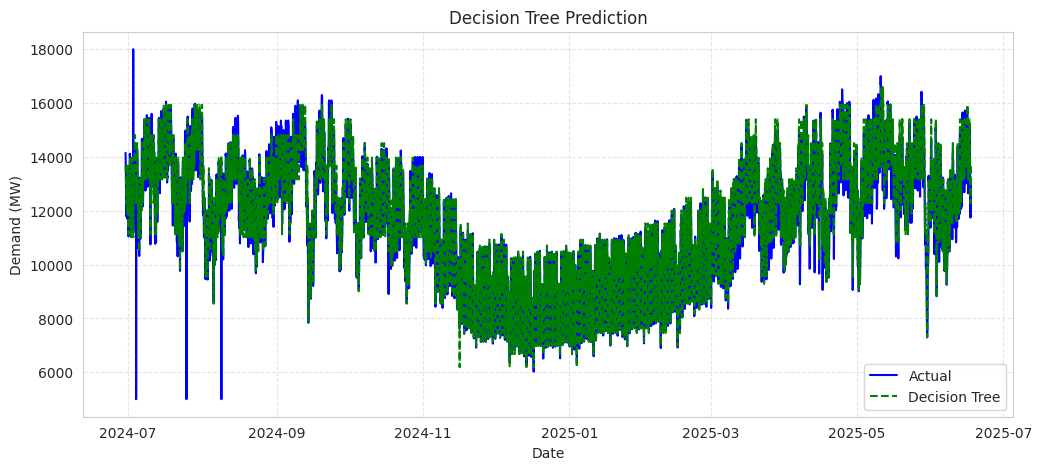

In [50]:
# Decision Tree prediction plot
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Actual', color='blue')           # Real demand
plt.plot(y_test.index, dt_pred, label='Decision Tree', color='green', linestyle='--')  # Predicted by Decision Tree
plt.title("Decision Tree Prediction")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


#Random Forest

In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error
rf_model=RandomForestRegressor(n_estimators=200,
                               max_depth=8,
                               min_samples_split=5,
                               min_samples_leaf=2,
                               random_state=42)
rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
mae_rf = mean_absolute_error(y_test, rf_pred)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Random Forest RMSE: 338.21833190178086
Random Forest MAE: 199.08946038367282


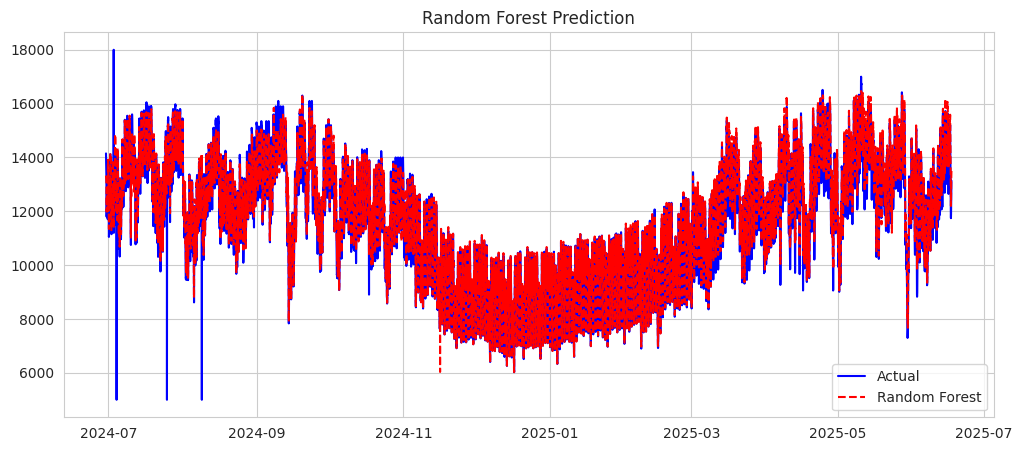

In [52]:

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Actual', color='blue')
plt.plot(y_test.index, rf_pred, label='Random Forest', color='red', linestyle='--')
plt.title("Random Forest Prediction")
plt.legend()
plt.show()


#XGBoost

In [53]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

In [54]:
model_xgb=XGBRegressor(n_estimators=2500,
                       early_stopping_rounds=50,
                       learning_rate=0.005,
                       max_depth=7,
                       min_child_weight=3,
                       gamma=1,
                       subsample=0.8,
                       reg_alpha=0.1,
                       reg_lambda=1.5,
                       random_state=42,
                       objective="reg:squarederror")

In [55]:
model_xgb.fit(x_train,y_train,eval_set=[(x_train,y_train),(x_test,y_test)],verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.005, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2500,
             n_jobs=None, num_parallel_tree=None, ...)

In [56]:
predictions_xgb=model_xgb.predict(x_test)
rmse_xgb=np.sqrt(mean_squared_error(y_test,predictions_xgb))
mae_xgb=mean_absolute_error(y_test,predictions_xgb)
print("XGBoost RMSE:",rmse_xgb)
print("XGBoost MAE:",mae_xgb)

XGBoost RMSE: 305.40383101722875
XGBoost MAE: 179.52255249023438


Text(65.72222222222221, 0.5, 'Demand')

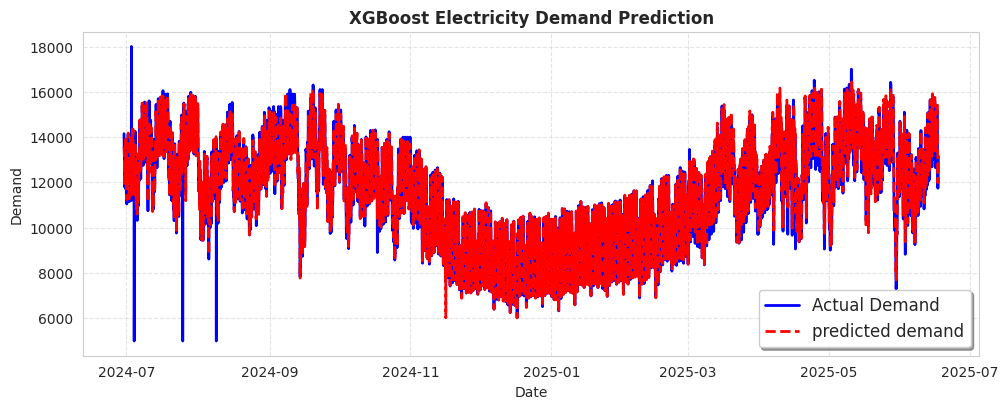

In [57]:
plt.figure(figsize=(10,4))
plt.plot(y_test.index,y_test,label="Actual Demand",color="Blue", linewidth=2)
plt.plot(y_test.index,predictions_xgb,label="predicted demand",color='Red',linestyle="--", linewidth=2)
plt.title("XGBoost Electricity Demand Prediction",fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend(fontsize=12, shadow=True)

plt.xlabel("Date")
plt.ylabel("Demand")

In [58]:
from sklearn.metrics import r2_score
r2_dt=r2_score(y_test,dt_pred)
r2_rf=r2_score(y_test,rf_pred)
r2_xgb=r2_score(y_test,predictions_xgb)

print("Decision Tree R2: ",r2_dt)
print("Random Forest R2:",r2_rf)
print("XGBoost R2: ",r2_xgb)




Decision Tree R2:  0.9656560006832295
Random Forest R2: 0.976426581838068
XGBoost R2:  0.9807789325714111
